In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\sentiment_analysis\raw_analyst_ratings.csv", encoding='latin1', skiprows=[1])
print(df.shape)
df.head()

(1407327, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
1,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
2,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
3,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
4,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A


In [ ]:
df["headline_length"] = df["headline"].astype(str).apply(len)
df["headline_length"].describe()

count    1.407327e+06
mean     7.313788e+01
std      4.073847e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.130000e+02
Name: headline_length, dtype: float64

Visual distribution

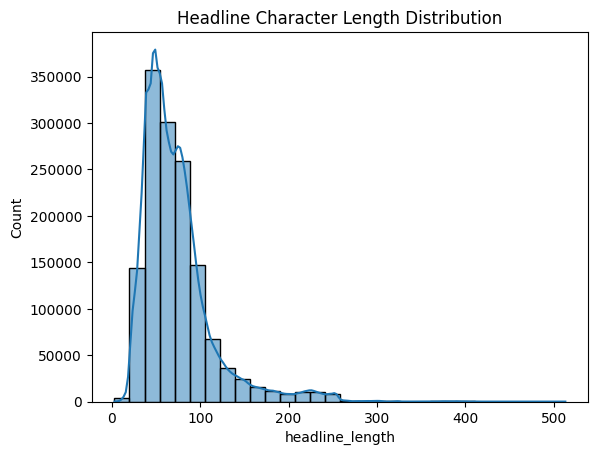

In [ ]:

sns.histplot(df["headline_length"], bins=30, kde=True)
plt.title("Headline Character Length Distribution")
plt.show()

Count Articles per Publisher

In [ ]:
publisher_counts = df["publisher"].value_counts()

print(publisher_counts.head(10))

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


Plot top publishers

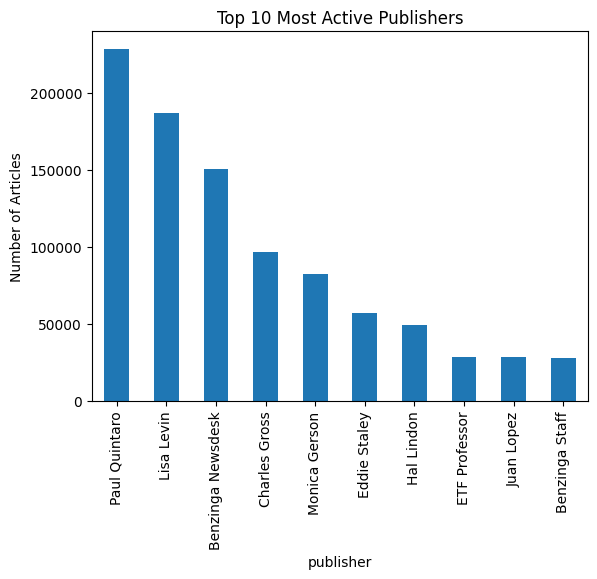

In [ ]:
publisher_counts.head(10).plot(kind="bar")
plt.title("Top 10 Most Active Publishers")
plt.ylabel("Number of Articles")
plt.show()

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

Articles per day

In [ ]:
daily_counts = df.groupby(df["date"].dt.date).size()

plot trend

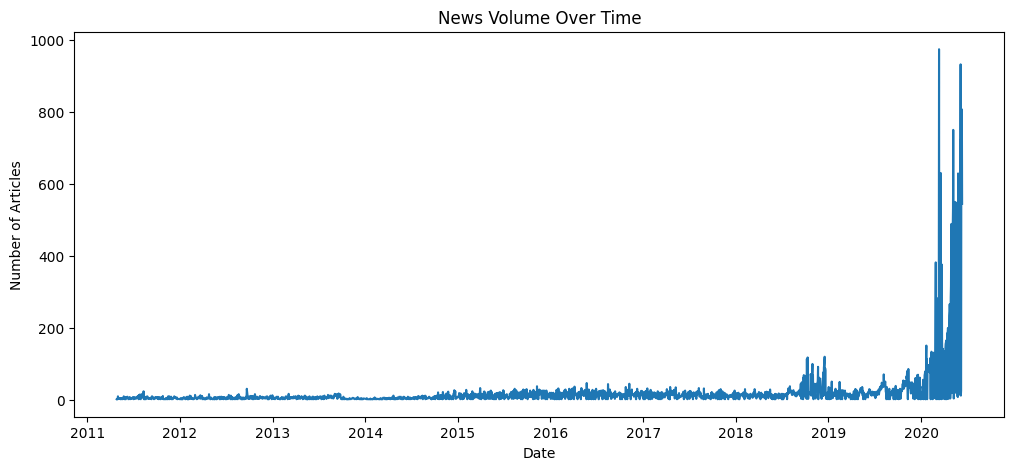

In [ ]:
daily_counts.plot(figsize=(12,5))
plt.title("News Volume Over Time")
plt.ylabel("Number of Articles")
plt.xlabel("Date")
plt.show()

Weekly Trend

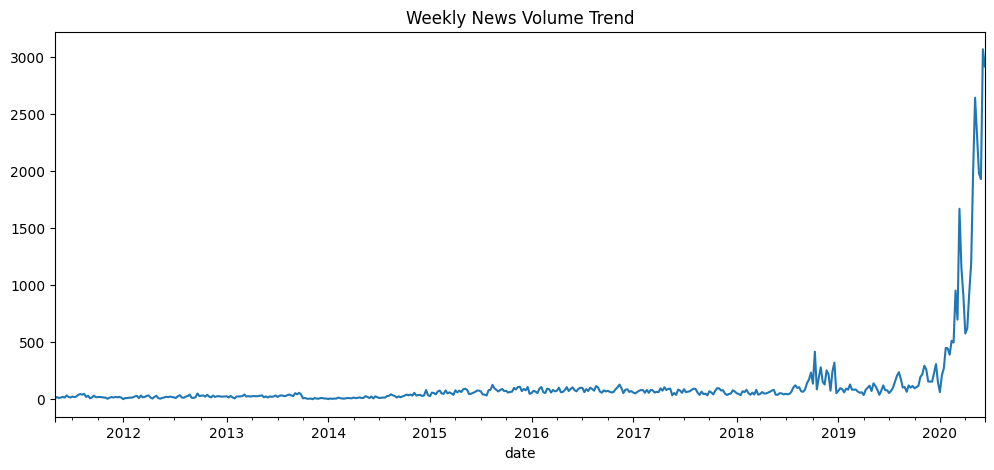

In [ ]:
weekly_counts = df.resample("W", on="date").size()

weekly_counts.plot(figsize=(12,5))
plt.title("Weekly News Volume Trend")
plt.show()

Detect Spikes in News Volume

In [ ]:
mean = weekly_counts.mean()
std = weekly_counts.std()

spikes = weekly_counts[weekly_counts > mean + 2 * std]

print(spikes)

date
2020-03-01 00:00:00-04:00     954
2020-03-15 00:00:00-04:00    1671
2020-03-22 00:00:00-04:00    1156
2020-03-29 00:00:00-04:00     910
2020-04-19 00:00:00-04:00     929
2020-04-26 00:00:00-04:00    1194
2020-05-03 00:00:00-04:00    1994
2020-05-10 00:00:00-04:00    2645
2020-05-17 00:00:00-04:00    2319
2020-05-24 00:00:00-04:00    1981
2020-05-31 00:00:00-04:00    1931
2020-06-07 00:00:00-04:00    3070
2020-06-14 00:00:00-04:00    2919
dtype: int64
